<a href="https://colab.research.google.com/github/arulperiyannagounder-collab/Training_Hands_on/blob/main/Restaurant_data_analysis_using_wordcloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data1=pd.read_csv('/content/drive/MyDrive/PLACEMENT AI/i1.csv')
data2=pd.read_csv('/content/drive/MyDrive/PLACEMENT AI/i2.csv')

In [ ]:
data=data1.merge(data2,how='outer')

In [ ]:
data.shape

(15621, 16)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [ ]:
data.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [ ]:
data.tail()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
15616,2023-09-19,2023-09-19 22:03:44,28389,Kulcha,55.0,1.0,55.0,0.0,2.76,57.76,16.0,biller,0,NaN,Indian Breads,NaN
15617,2023-09-19,2023-09-19 22:03:44,28389,Mineral Water,20.0,2.0,40.0,0.0,2.00,42.00,16.0,biller,0,NaN,Deserts & Mocktails,NaN
15618,2023-09-19,2023-09-19 22:03:44,28389,Mushroom Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15619,2023-09-19,2023-09-19 22:03:44,28389,Paneer Butter Masala,150.0,1.0,150.0,0.0,7.50,157.50,16.0,biller,0,NaN,Veg Gravy,NaN
15620,2023-09-19,2023-09-19 22:03:44,28389,Parota,30.0,4.0,120.0,0.0,6.00,126.00,16.0,biller,0,NaN,Indian Breads,NaN


In [ ]:
data.describe()

,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [ ]:
data.isnull().sum()

,0
Date,0
Timestamp,0
Invoice No.,0
Item Name,0
Price,0
Qty.,0
Sub Total,0
Discount,0
Tax,0
Final Total,0


In [ ]:

data=data.drop(['Discount','Table No.','Server Name','Variation','Covers','HSN'],axis=1)

In [ ]:
sum=data['Final Total'].sum()
print(sum)

2397010.12


In [ ]:
nos=data['Invoice No.'].nunique()
print(nos)

4925


In [ ]:
avg_sal=sum/nos
print(avg_sal)

486.70256243654825


In [ ]:
item=data.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]


<Axes: xlabel='Item Name', ylabel='Qty.'>

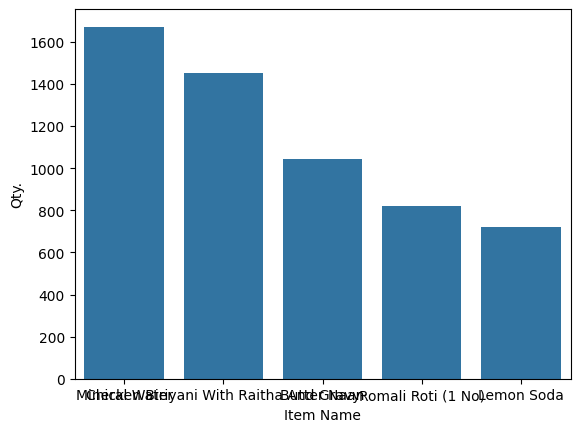

In [ ]:
sns.barplot(item)

<Axes: xlabel='Item Name'>

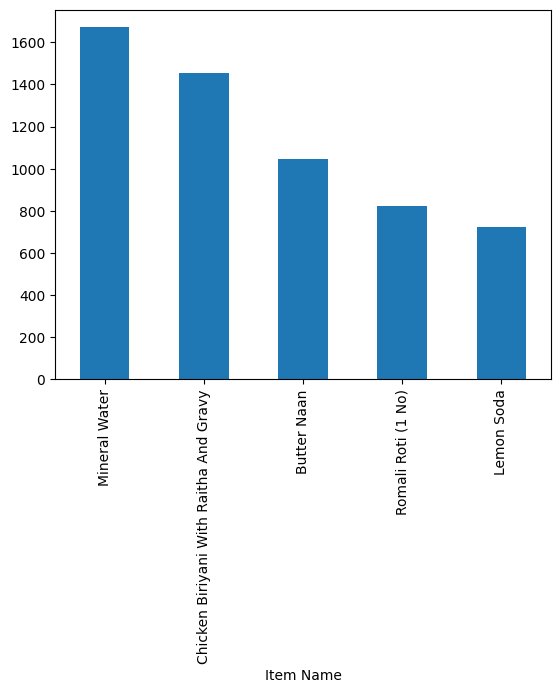

In [ ]:
item.plot(kind='bar')

<Axes: xlabel='Item Name'>

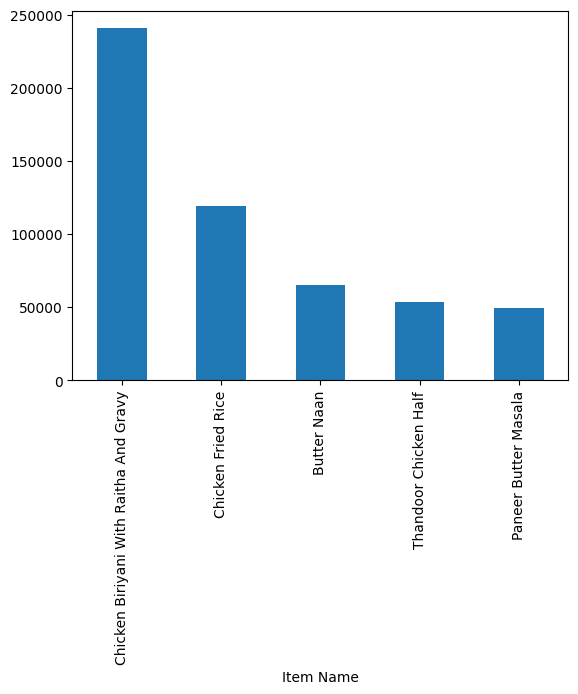

In [ ]:
itm=data.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:5]
itm.plot(kind='bar')

In [ ]:
data[(data['Date']=='2023-09-15') & (data['Item Name']=='Chicken Noodles')]['Qty.'].sum()

np.float64(7.0)

In [ ]:
it=data.groupby('Invoice No.')['Final Total'].sum()
it[it>2000]



,Final Total
Invoice No.,
23499,2533.64
23508,2011.00
23637,5644.82
23718,3517.50
23827,22638.00
...,...
28014,3013.68
28126,2887.50
28145,4078.68


In [ ]:
it[(it==2887.50)]

,Final Total
Invoice No.,
28126,2887.5


In [ ]:
data[data['Invoice No.']==28145]['Qty.'].sum()

np.float64(40.0)

np.float64(40.0)

In [ ]:
data[data['Invoice No.']==28145]['Item Name'].sum()


'Butter Chicken GravyButter Chicken GravyButter NaanChicken Biriyani With Raitha And GravyChicken Chettinad GravyChicken Pallipalayam GravyFish 65Garlic NaanGobi- 65Kadai PaneerKozhi MilaghuperattalMineral WaterPepper Tandoori Chicken ( Full )Pepper Tandoori Chicken ( Half )Romali Roti (1 No)Schewan  Chicken Fried RiceSchewan Chicken NoodleSchezwan Veg Noodles'

In [ ]:
data[data['Invoice No.']==28145]['Final Total'].sum()

np.float64(4078.68)

([], [])

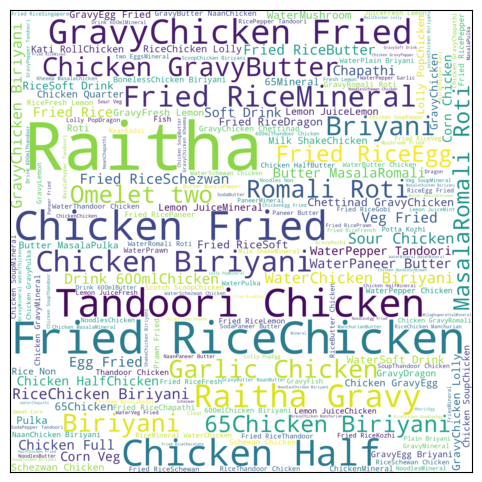

In [ ]:
from wordcloud import WordCloud
txt=''.join(data['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color='white',width=2000,height=2000). generate(txt)

fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
plt.xticks([])
plt.yticks([])


([], [])

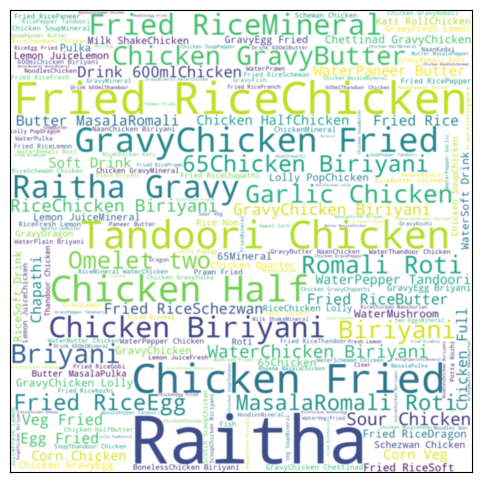

In [ ]:
txt=''.join(data['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color='white',width=2000,height=2000). generate(txt)

fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bicubic')
plt.xticks([])
plt.yticks([])


([], [])

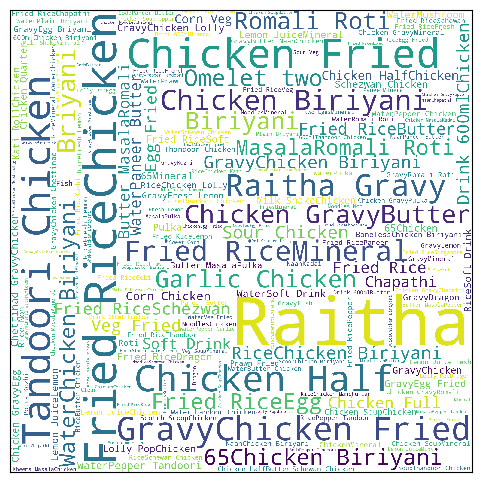

In [ ]:
txt=''.join(data['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color='white',width=2000,height=2000). generate(txt)

fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='nearest')
plt.xticks([])
plt.yticks([])


([], [])

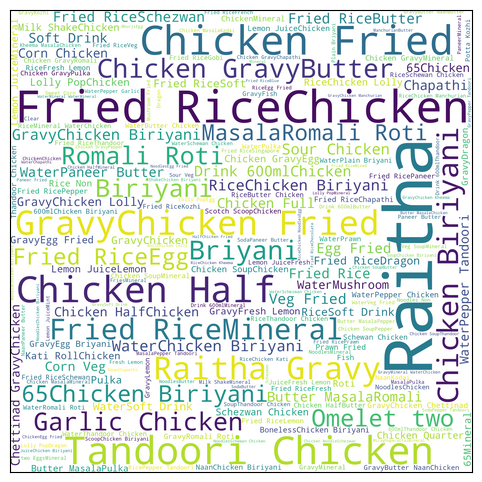

In [ ]:
txt=''.join(data['Item Name'].dropna().astype(str).values)
wordcloud=WordCloud(background_color='white',width=2000,height=2000). generate(txt)

fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='blackman')
plt.xticks([])
plt.yticks([])